# Geração de Gráficos para Artigo Científico (Padrão IEEE)
Este notebook gera visualizações para o artigo, aplicando as diretrizes de formatação (Times New Roman, 8pt).

In [1]:
import os
import h5py
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuração de Estilo do Artigo (IEEE Padrão)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

## 1. Carregamento e Preparação dos Dados

In [2]:
filename = '../data/N-CMAPSS_DS02-006.h5'
if not os.path.exists(filename):
    filename = 'data/N-CMAPSS_DS02-006.h5'

with h5py.File(filename, 'r') as hdf:
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))
    Y_dev = np.array(hdf.get('Y_dev'))
    A_dev = np.array(hdf.get('A_dev'))
    T_dev = np.array(hdf.get('T_dev')) # Variáveis de Degradação Reais (Gabarito)
    
    W_var = [v.decode('utf-8') for v in np.array(hdf.get('W_var'))]
    X_s_var = [v.decode('utf-8') for v in np.array(hdf.get('X_s_var'))]
    T_var = [v.decode('utf-8') for v in np.array(hdf.get('T_var'))]

A_var = ['unit', 'cycle', 'Fc', 'hs']

df_A = pd.DataFrame(A_dev, columns=A_var)
df_W = pd.DataFrame(W_dev, columns=W_var)
df_Xs = pd.DataFrame(X_s_dev, columns=X_s_var)
df_Y = pd.DataFrame(Y_dev, columns=['RUL'])
df_T = pd.DataFrame(T_dev, columns=T_var)

df_completo = pd.concat([df_A, df_W, df_Xs, df_Y, df_T], axis=1)

print("Dados carregados com sucesso.")

Dados carregados com sucesso.


## 2. Matriz de Correlação

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

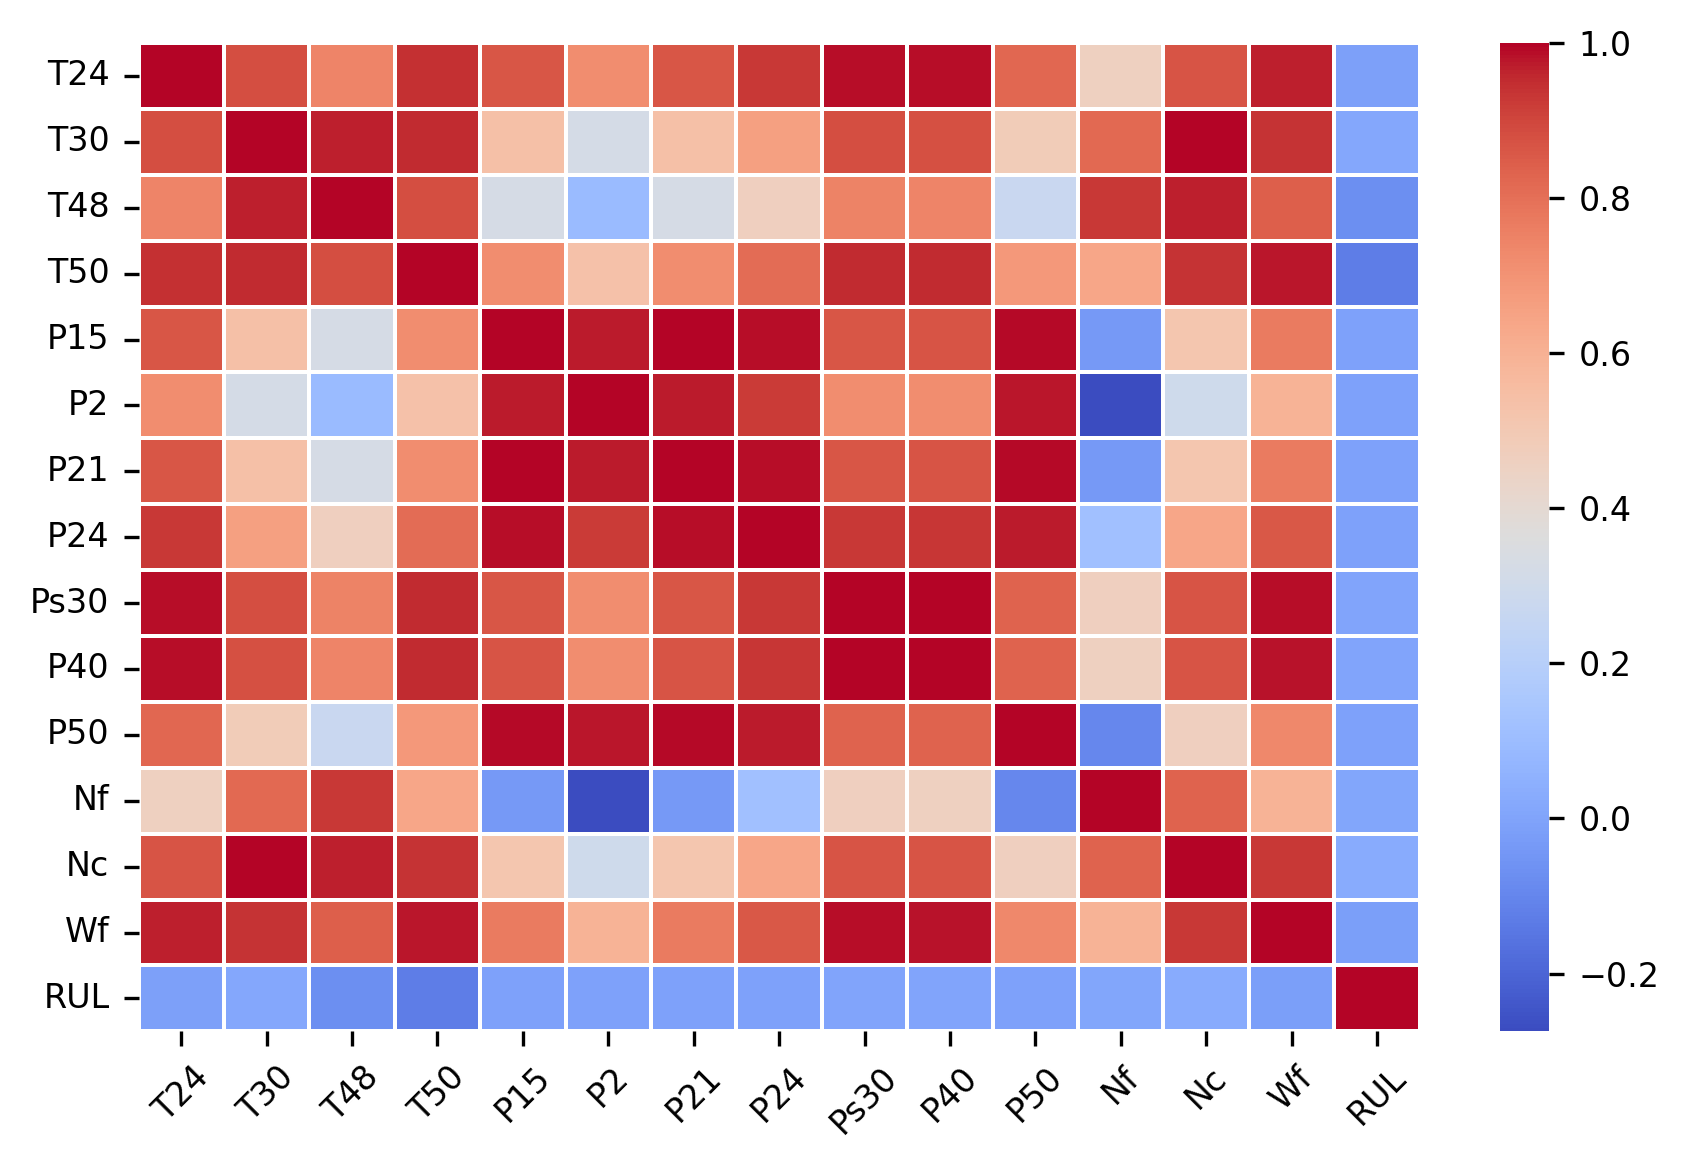

In [3]:
sensores = list(X_s_var)
cols_to_corr = sensores + ['RUL']
df_corr = df_completo[cols_to_corr].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(df_corr, cmap='coolwarm', cbar=True, annot=False, linewidths=0.5)
# plt.title('Correlation Matrix: Physical Sensors vs RUL')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig/fig_correlation_matrix.png')
plt.show()

## 3. Distribuição de Sensores

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

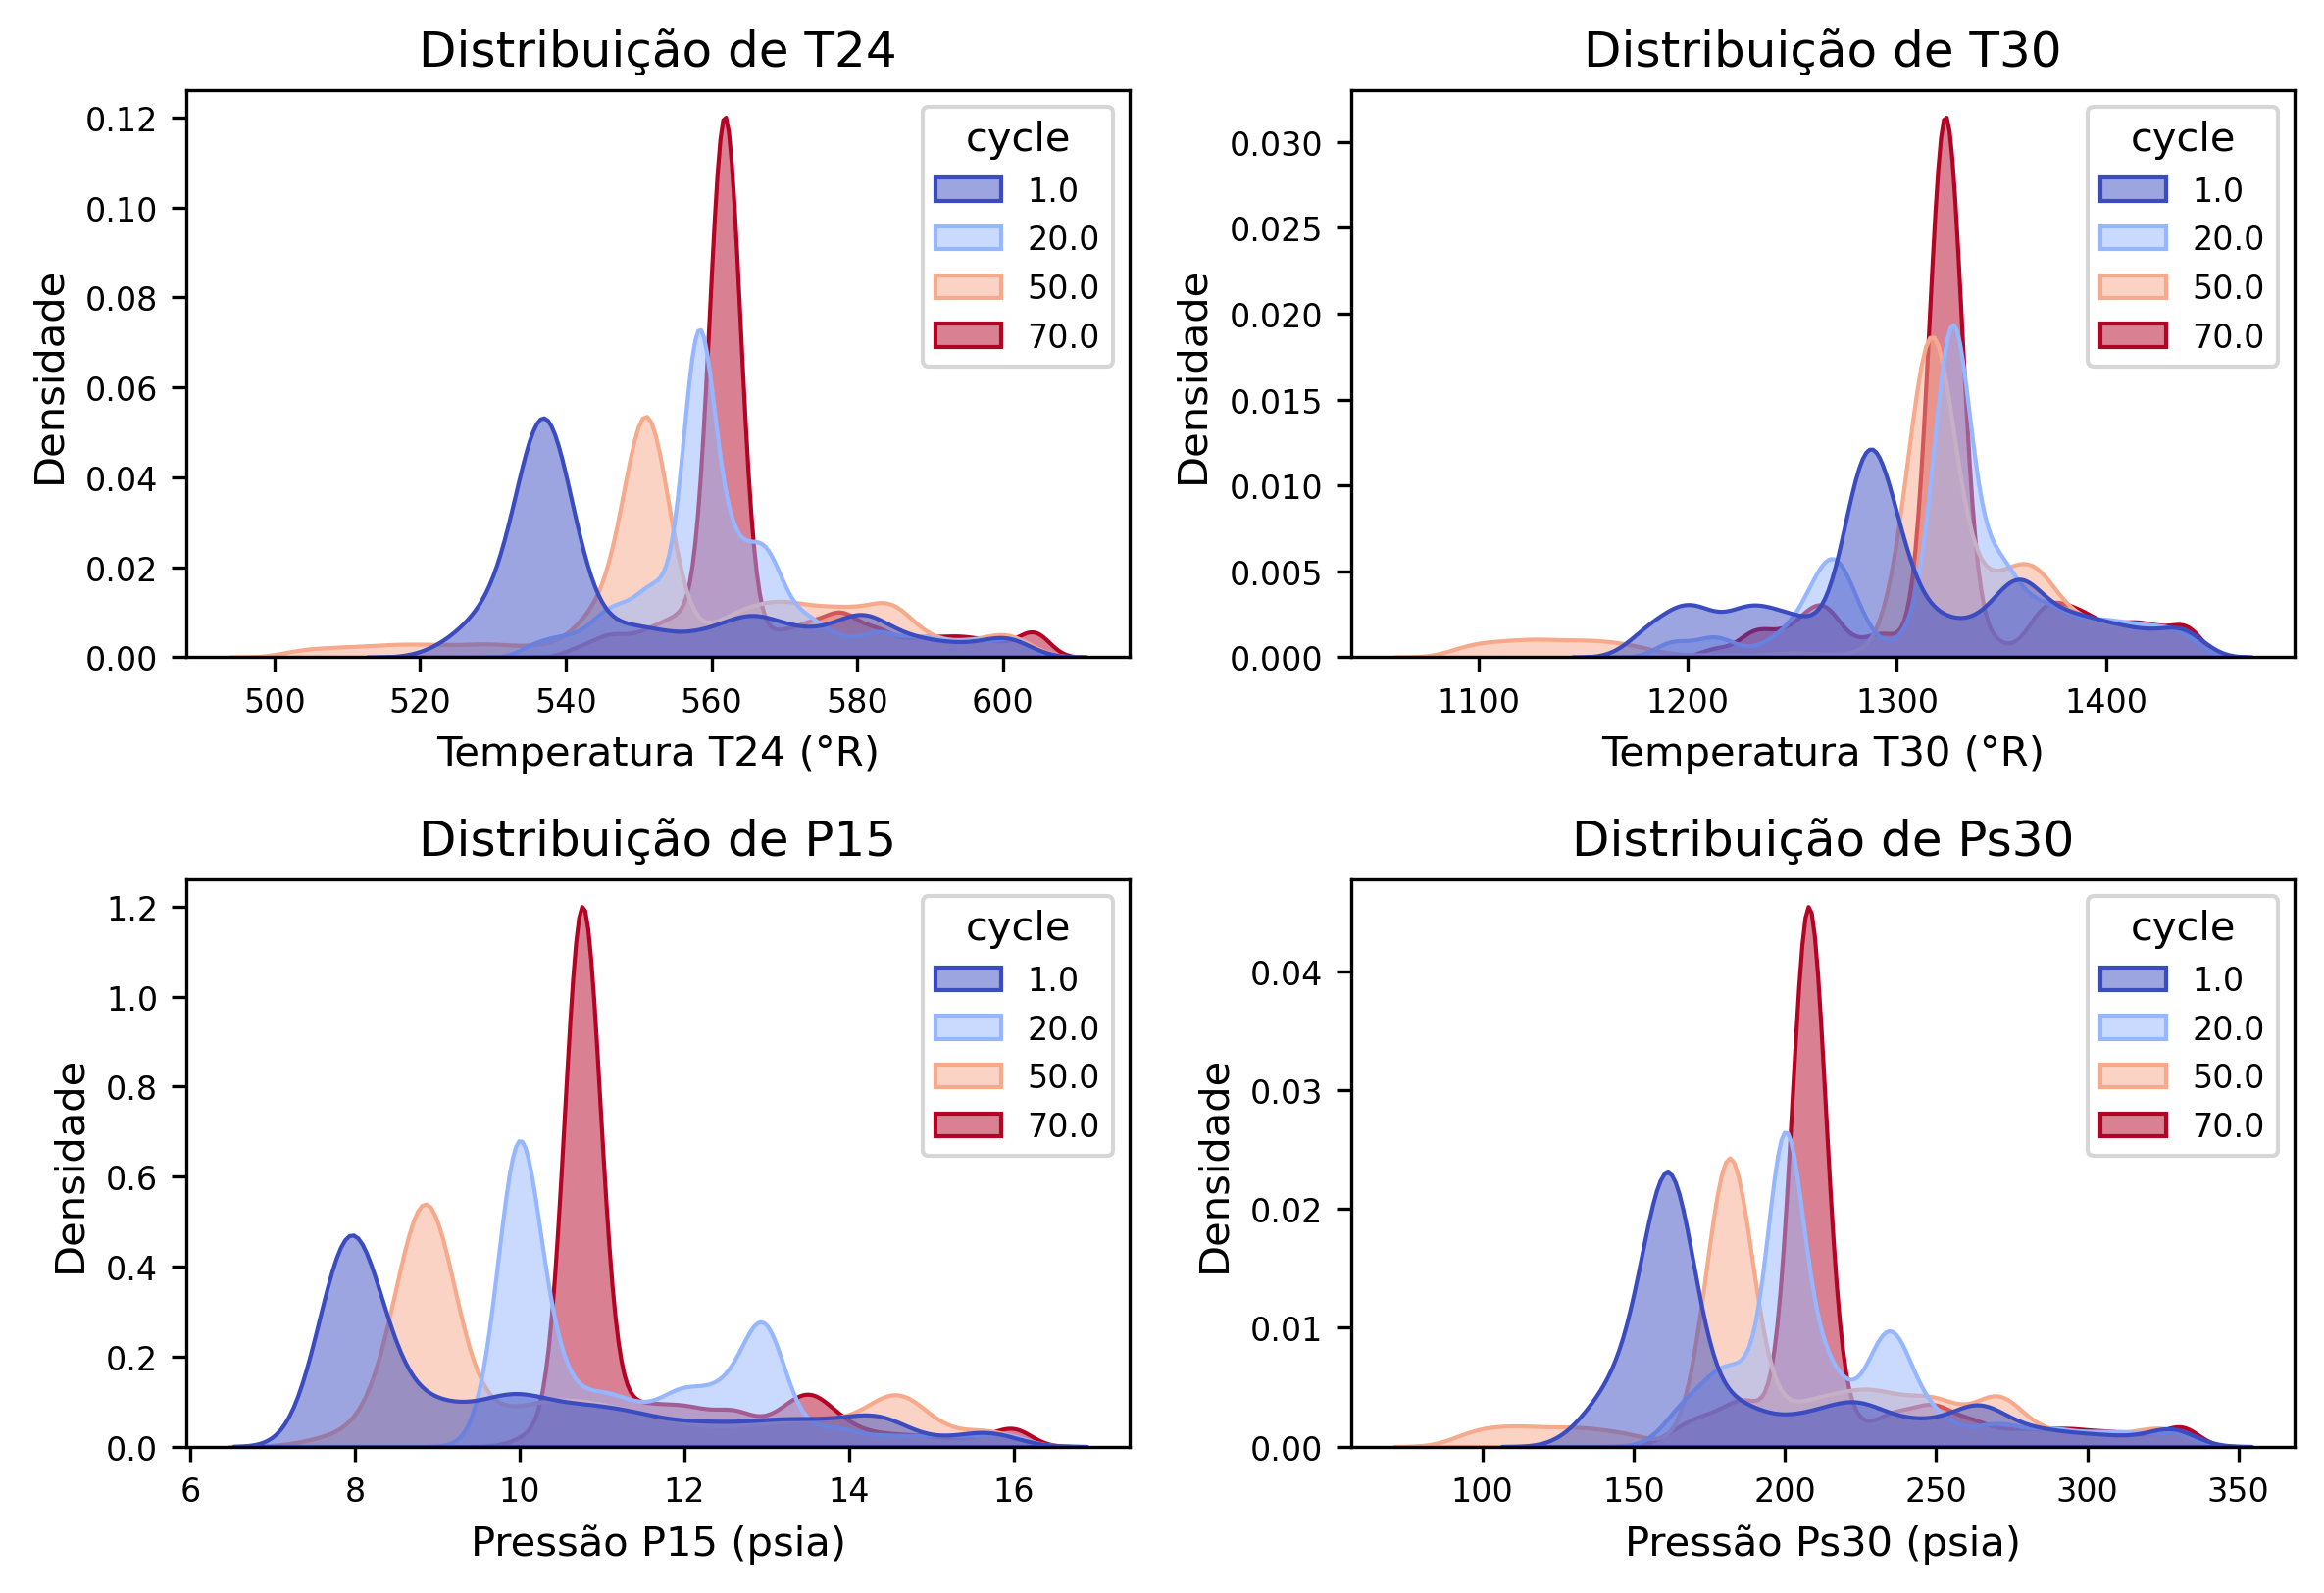

In [8]:
sensores_chave = ['T24', 'T30', 'P15', 'Ps30']
df_xs_plot = df_completo[(df_completo['unit'] == 2.0) & (df_completo['cycle'].isin([1, 20, 50, 70]))].copy()

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
#fig.suptitle('Desvio na Distribuição dos Sensores ao Longo dos Ciclos de Voo (Unidade 2)', fontsize=14)

for i, sensor in enumerate(sensores_chave):
    ax = axes[i//2, i%2]
    sns.kdeplot(data=df_xs_plot, x=sensor, hue='cycle', ax=ax, fill=True, palette='coolwarm', common_norm=False, alpha=0.5)
    ax.set_title(f'Distribuição de {sensor}')
    ax.set_ylabel('Densidade')
    
    if sensor.startswith('T'):
        ax.set_xlabel(f'Temperatura {sensor} (°R)')
    elif sensor.startswith('P'):
        ax.set_xlabel(f'Pressão {sensor} (psia)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('fig/fig_sensor_distribution.png')
plt.show()

## 4. Análise PCA (Separação de Estados Saudável vs Falho)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

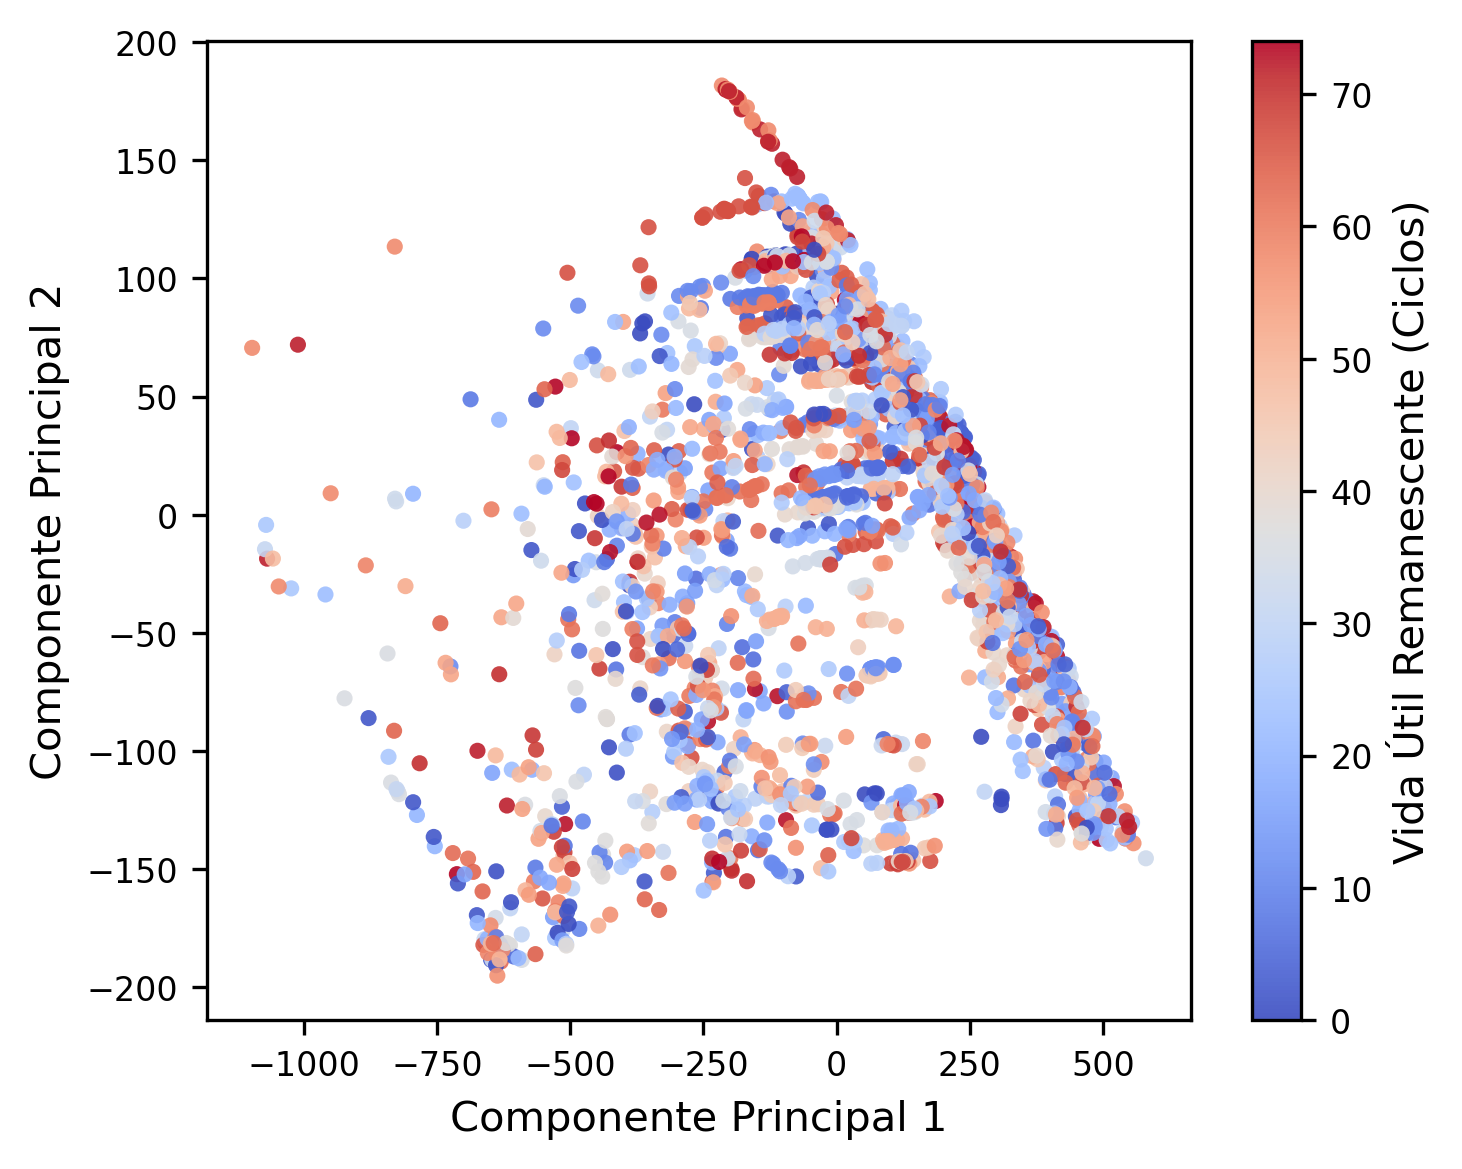

In [ ]:
# Para ficar bem legível, é usado uma amostra pequena e marcadores maiores
df_pca_sample = df_completo[df_completo['unit'] <= 3.0].sample(n=3000, random_state=42)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_pca_sample[sensores])

plt.figure(figsize=(5, 4))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_pca_sample['RUL'], cmap='coolwarm', s=15, alpha=0.9, edgecolors='none')
cbar = plt.colorbar(scatter)
cbar.set_label('Vida Útil Remanescente (Ciclos)')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
# plt.title('Sensor Space PCA Projection (Healthy vs Faulty State)')
plt.tight_layout()
plt.savefig('fig/fig_pca_analysis.png')
plt.show()

## 5. Impacto Direto do Voo no Sensor
Mostrando que o sensor flutua enormemente só pelas manobras do avião, exigindo um modelo capaz de filtrar esse ruído.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

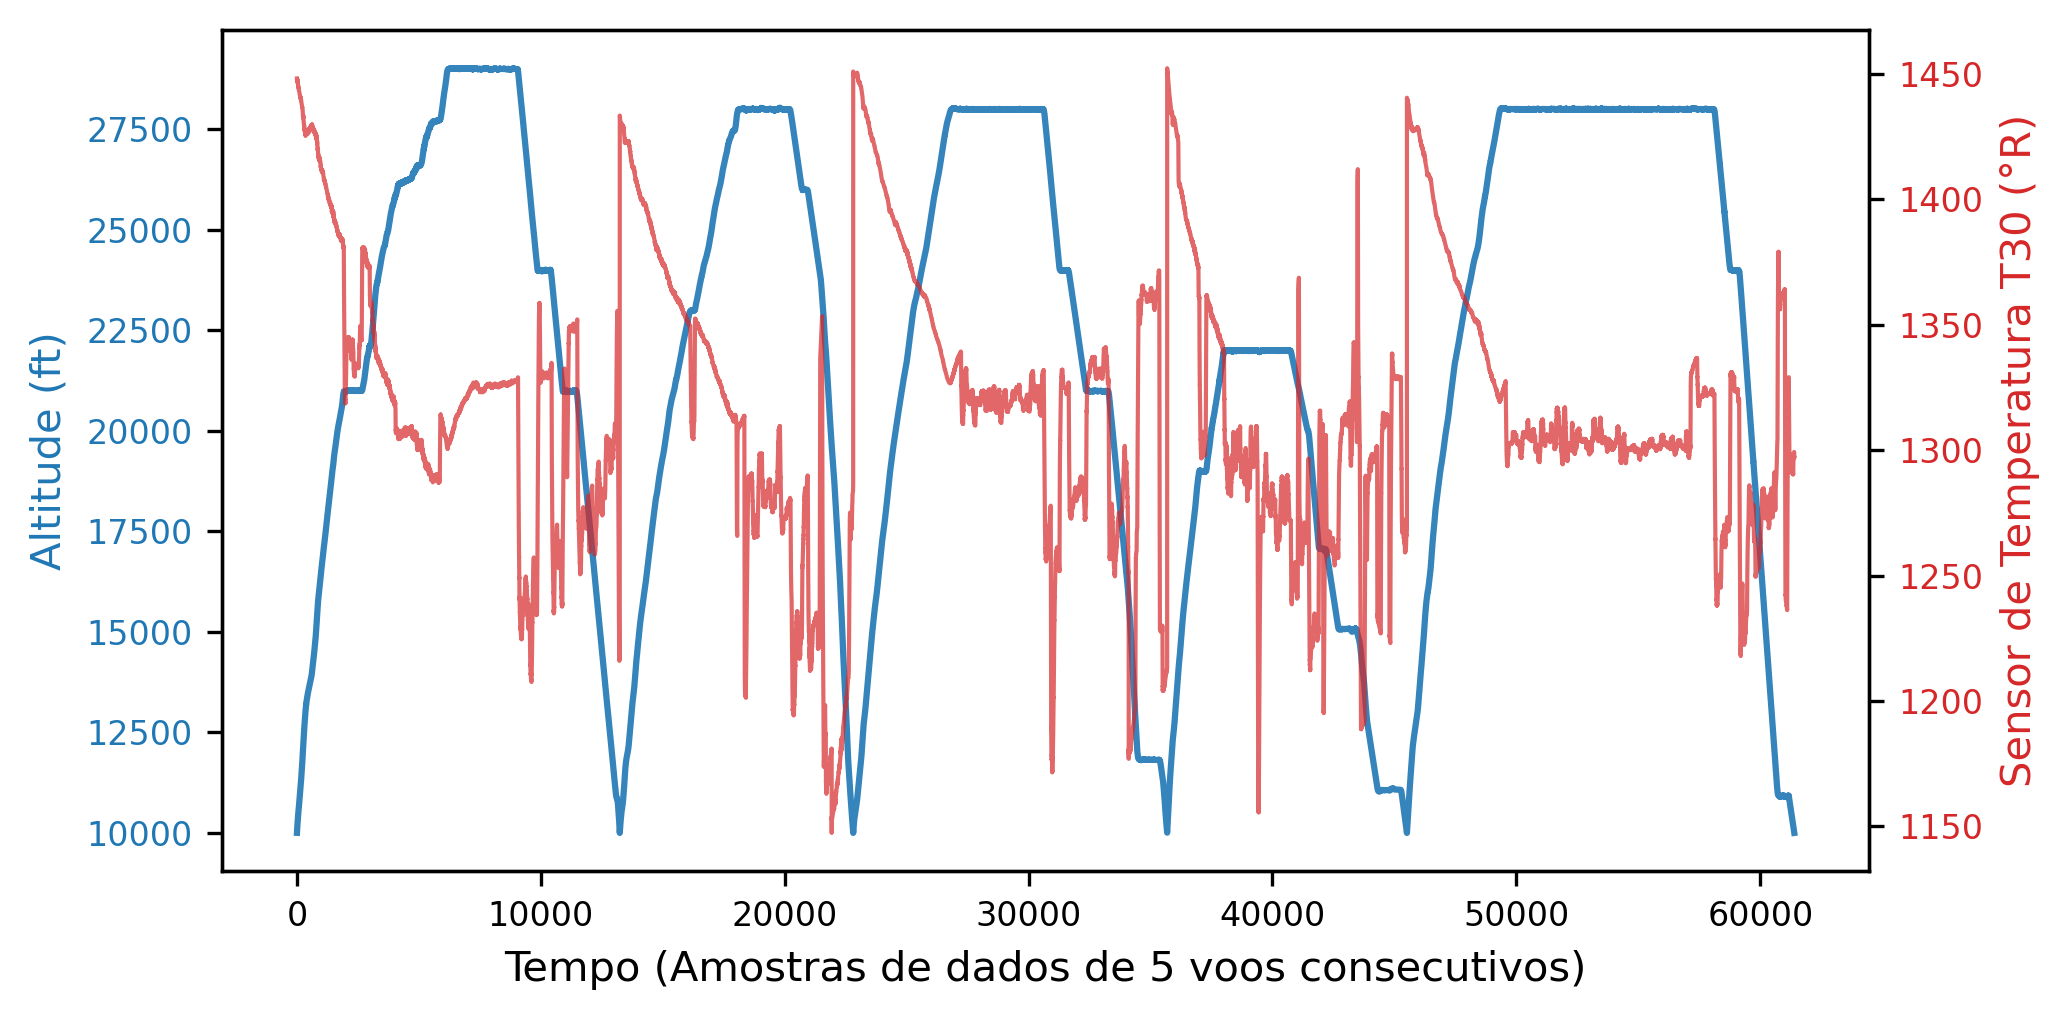

In [10]:
# Pegando 5 voos consecutivos (Ciclos 10 a 14) do Motor 2
df_flight = df_completo[(df_completo['unit'] == 2.0) & (df_completo['cycle'].isin([10, 11, 12, 13, 14]))].reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(7, 3.5))

color1 = 'tab:blue'
ax1.set_xlabel('Tempo (Amostras de dados de 5 voos consecutivos)')
ax1.set_ylabel('Altitude (ft)', color=color1)

# Plotando a altitude
ax1.plot(df_flight.index, df_flight['alt'], color=color1, linewidth=1.5, alpha=0.9, label='Altitude')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Sensor de Temperatura T30 (°R)', color=color2)

# Plotando o sensor físico real
ax2.plot(df_flight.index, df_flight['T30'], color=color2, linewidth=1, alpha=0.7, label='T30')
ax2.tick_params(axis='y', labelcolor=color2)

# plt.title('Progressive Wear Hidden Under Flight Operational Noise (5 Flights Snapshot)')
fig.tight_layout()
plt.savefig('fig/fig_flight_impact.png')
plt.show()

## 6. Fleet Analysis (Trajetória de Degradação Real - Gabarito)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

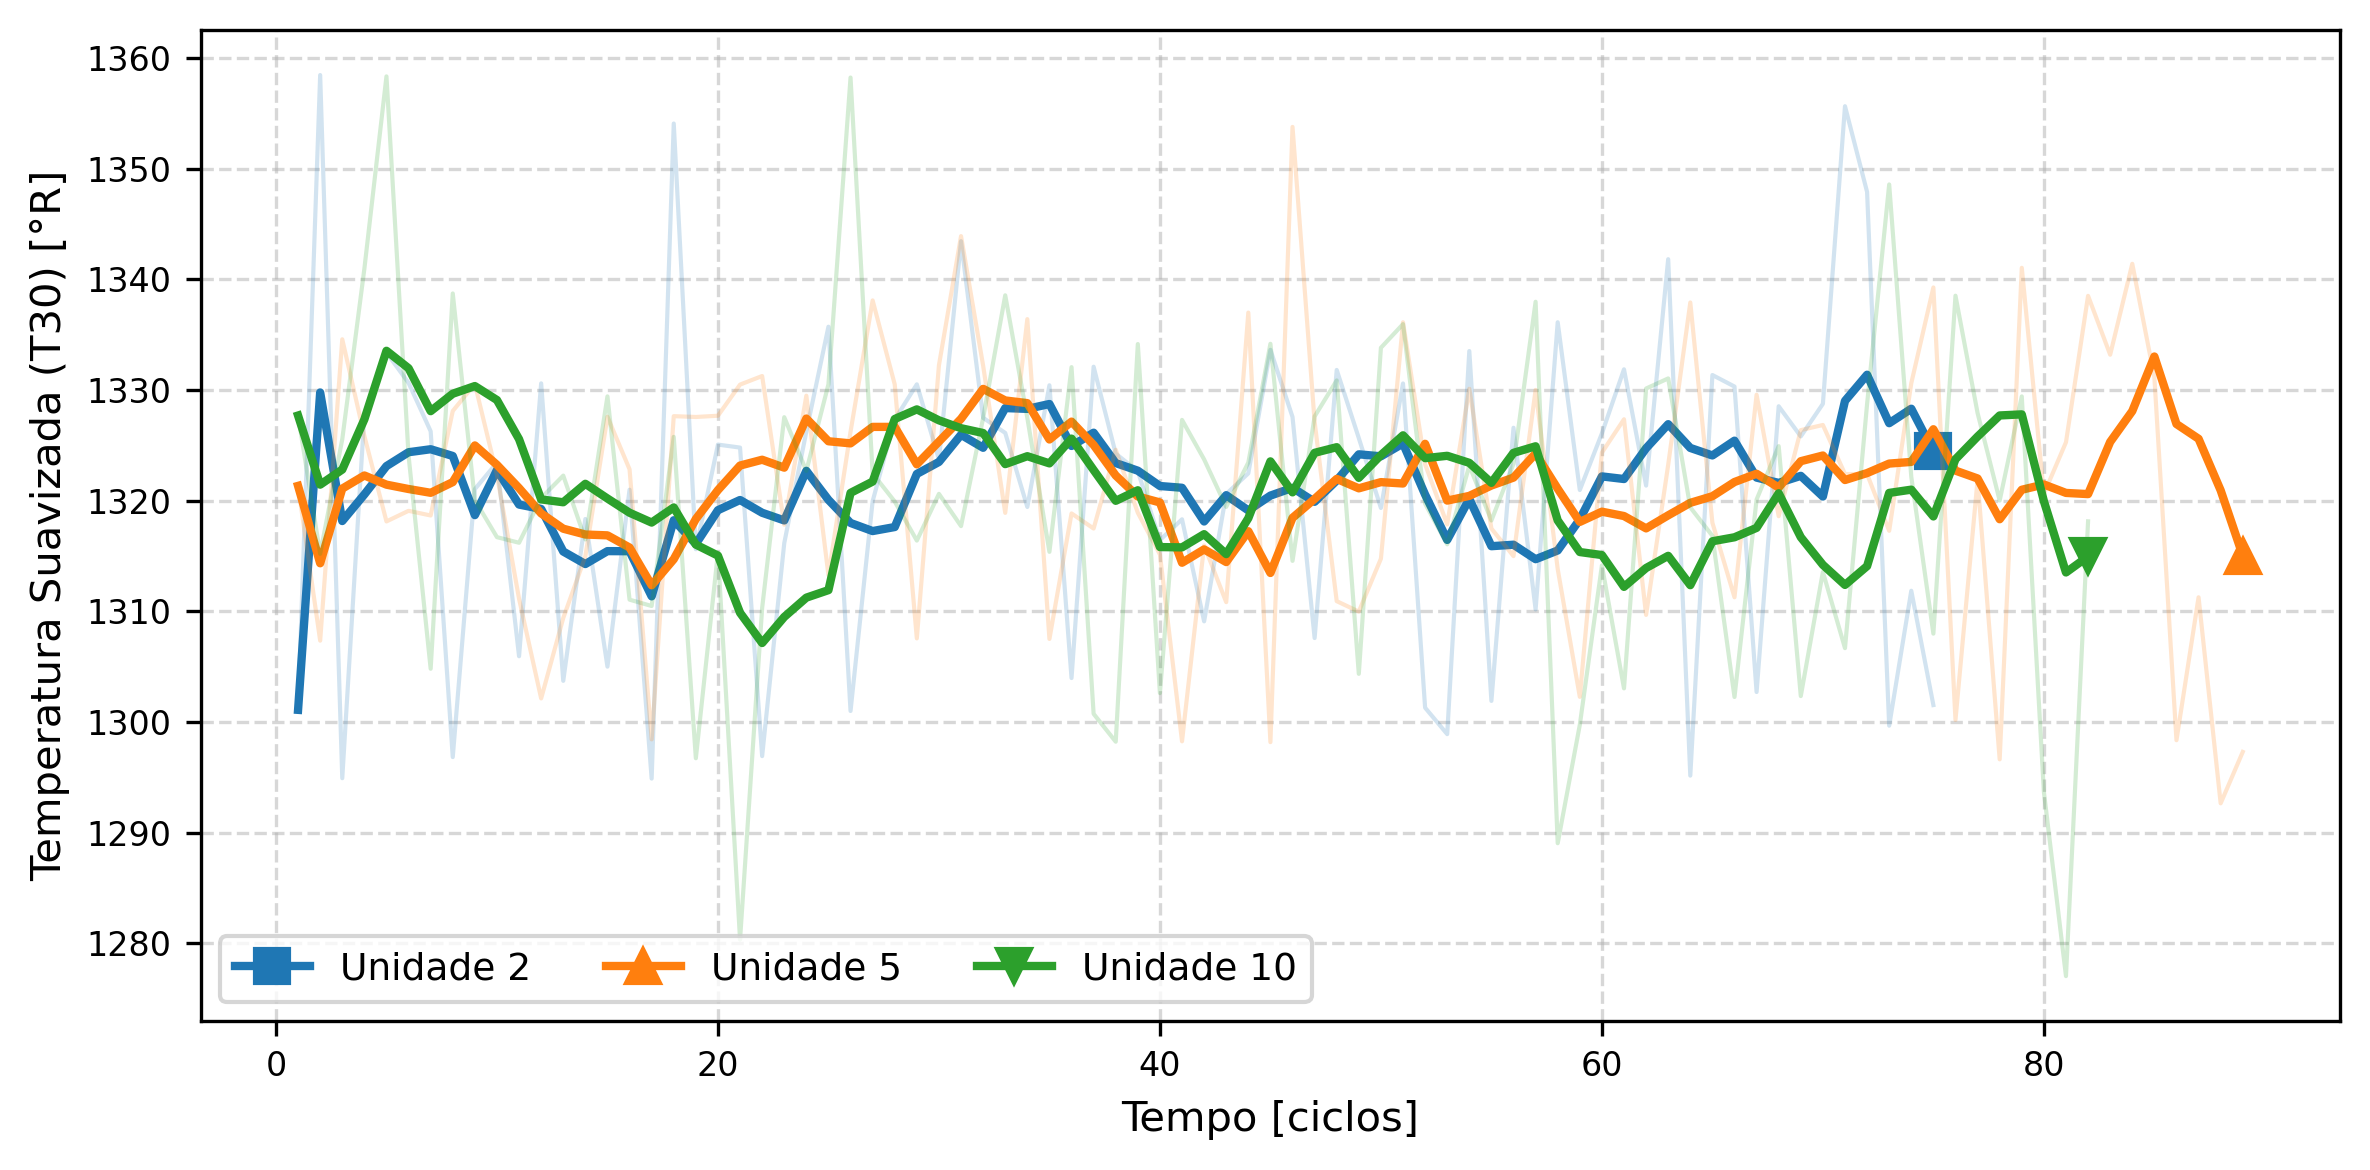

In [11]:
# Plotar a trajetória de degradação térmica (T30) suavizada
unidades = [2, 5, 10] 
markers = ['s', '^', 'v']
colors = sns.color_palette("tab10", len(unidades))

plt.figure(figsize=(8, 4))

for idx, u in enumerate(unidades):
    df_u = df_completo[df_completo['unit'] == u]

    # Pega a média térmica (T30) por ciclo
    df_cycle = df_u.groupby('cycle')['T30'].mean().reset_index()
    
    # Aplicar Filtro de Média Móvel (Janela de 7 voos) para revelar a tendência
    df_cycle['T30_smooth'] = df_cycle['T30'].rolling(window=7, min_periods=1).mean()
    
    # 1. Plota a linha original (com ruído) fina e transparente no fundo
    plt.plot(df_cycle['cycle'], df_cycle['T30'], color=colors[idx], alpha=0.2, linewidth=1)
    
    # 2. Plota a tendência suavizada forte com marcador APENAS no último ponto (markevery=[-1])
    plt.plot(df_cycle['cycle'], df_cycle['T30_smooth'], 
             marker=markers[idx], markevery=[-1], markersize=8, 
             color=colors[idx], label=f'Unidade {int(u)}', linewidth=2)

# Tradução e formatação dos eixos
plt.xlabel('Tempo [ciclos]')
plt.ylabel('Temperatura Suavizada (T30) [°R]')
# plt.title('Trajetória de Degradação Térmica Múltiplas Unidades')
plt.grid(True, linestyle='--', alpha=0.5)

# Legenda limpa
plt.legend(loc='lower left', ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig('fig/fig_fleet_analysis.png')
plt.show()
